In [60]:
# import kagglehub

# kagglehub.login()
# # API KEY = KGAT_08745a6f63206ccfcbef8fdf0c5d17e9

In [1]:
%load_ext autoreload
%autoreload 2

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import optuna
from config_file import config
from utils import (
    FeatureEngineer, 
    preprocessor, 
    logistic_kfold,
    pipeline_return, 
    add_result, 
    plot_feature_importance
)
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    train_test_split,
    GridSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings('ignore')

plt.style.use("fivethirtyeight")
%matplotlib inline

In [4]:
train_data = pd.read_csv(config.paths.path_to_train)
train_data.set_index('PassengerId', inplace=True)

test_data = pd.read_csv(config.paths.path_to_test)
test_data.set_index('PassengerId', inplace=True)

In [5]:
train, test = train_data.copy(deep=True), test_data.copy(deep=True)
df = train

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


### EDA (Exploratory Data Analysis)

In [65]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


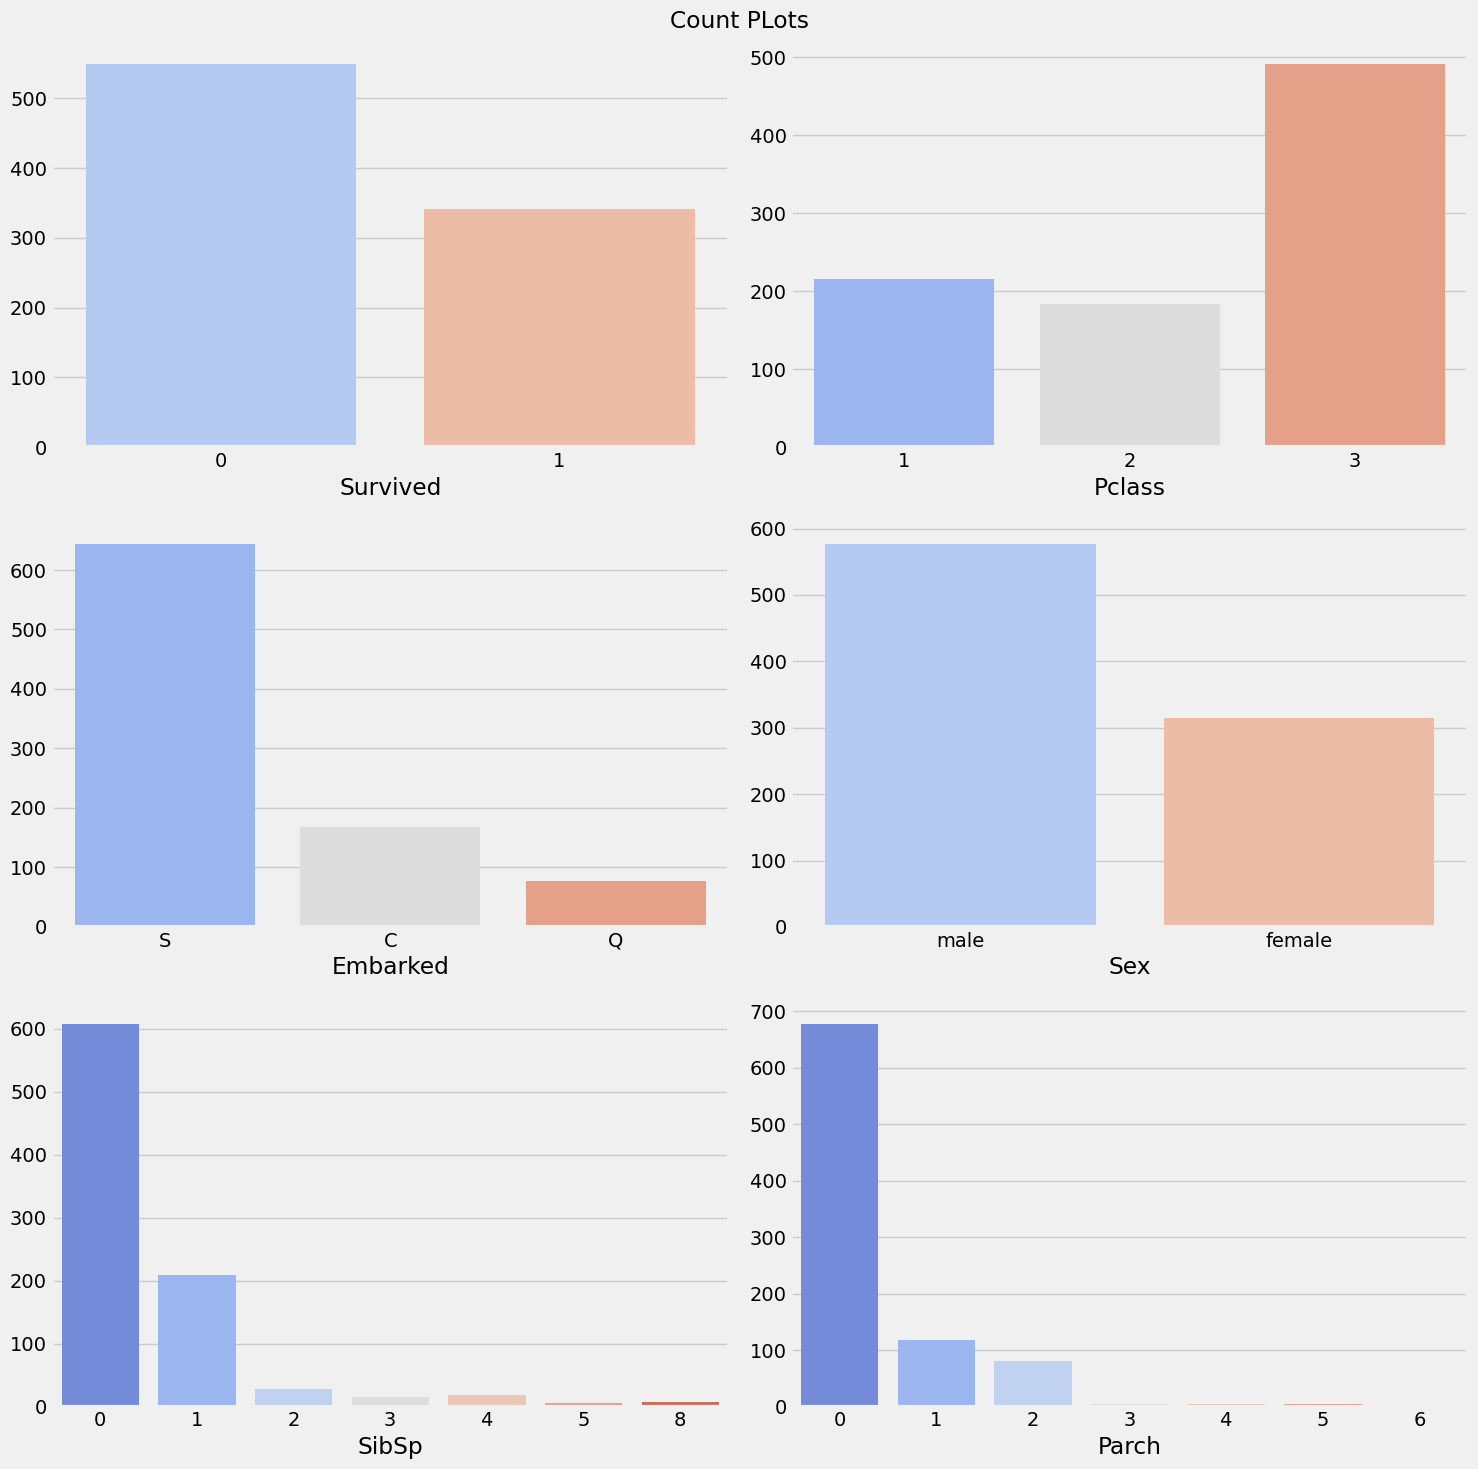

In [67]:
fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(15,15))

fig.suptitle('Count PLots')

sns.countplot(df, x=config.target_column_name, palette='coolwarm', ax=ax[0, 0])
sns.countplot(df, x='Pclass', palette='coolwarm', ax=ax[0, 1])
sns.countplot(df, x='Embarked', palette='coolwarm', ax=ax[1, 0])
sns.countplot(df, x='Sex', palette='coolwarm', ax=ax[1, 1])
sns.countplot(df, x='SibSp', palette='coolwarm', ax=ax[2, 0])
sns.countplot(df, x='Parch', palette='coolwarm', ax=ax[2, 1])

[ax[i, j].set_ylabel('') for i in range(3) for j in range(2)]

plt.tight_layout()
plt.show()

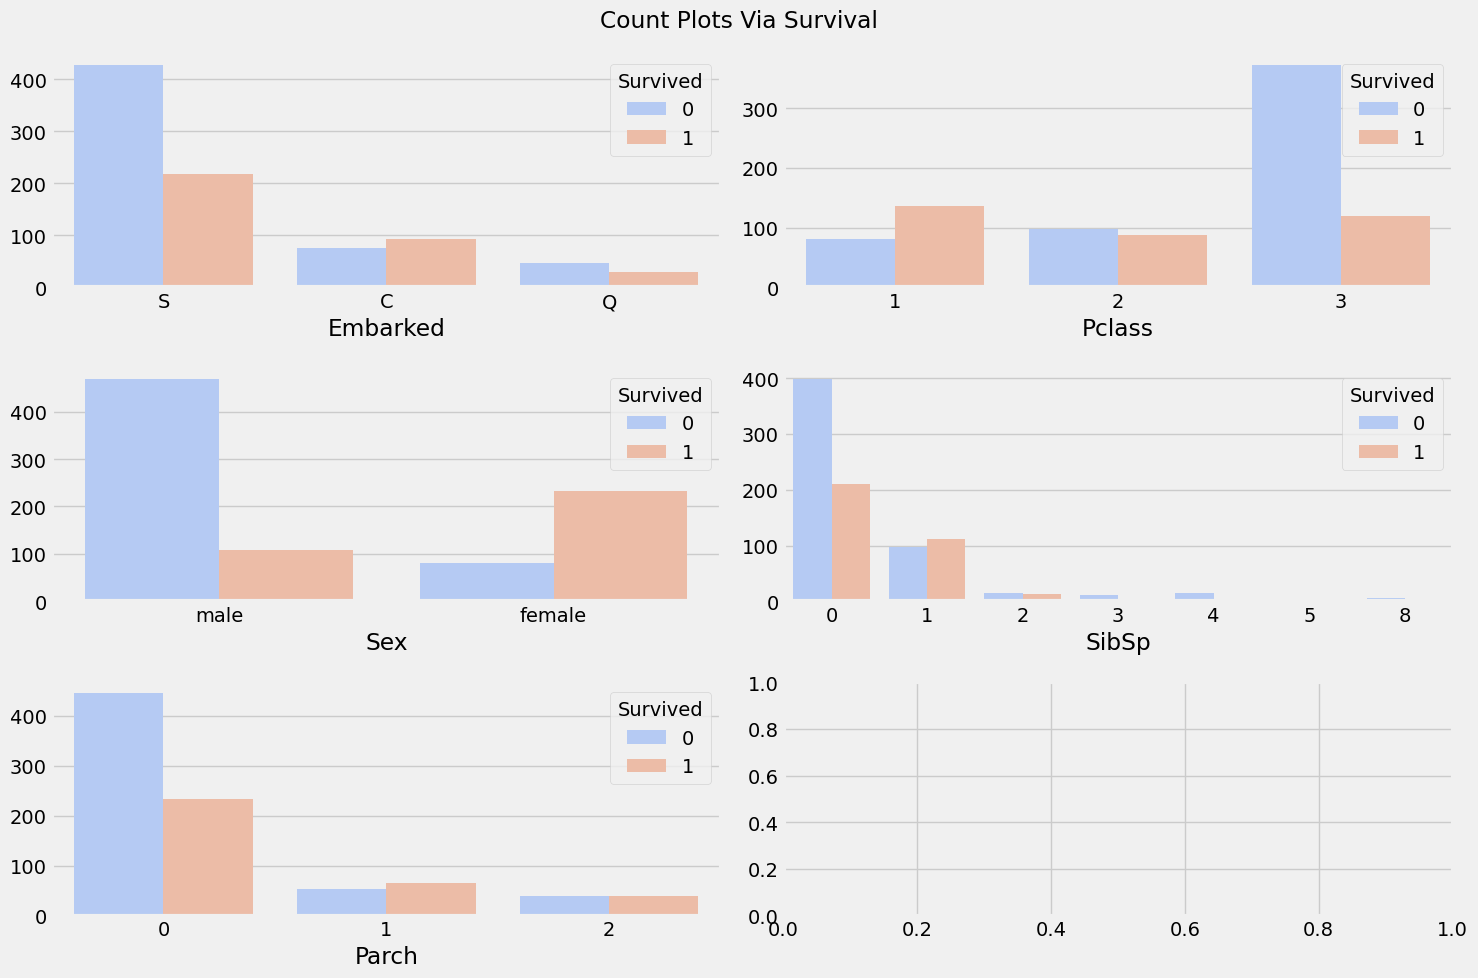

In [68]:
fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(15,10))

fig.suptitle('Count Plots Via Survival')

sns.countplot(df, x='Embarked', palette='coolwarm', hue=config.target_column_name, ax=ax[0, 0])
sns.countplot(df, x='Pclass', palette='coolwarm', hue=config.target_column_name, ax=ax[0, 1])
sns.countplot(df, x='Sex', palette='coolwarm', hue=config.target_column_name, ax=ax[1, 0])
sns.countplot(df, x='SibSp', palette='coolwarm', hue=config.target_column_name, ax=ax[1, 1])
sns.countplot(df, x='Parch', palette='coolwarm', hue=config.target_column_name, order=[0, 1, 2], ax=ax[2, 0])

[ax[i, j].set_ylabel('') for i in range(3) for j in range(2)]

plt.tight_layout()
plt.show()

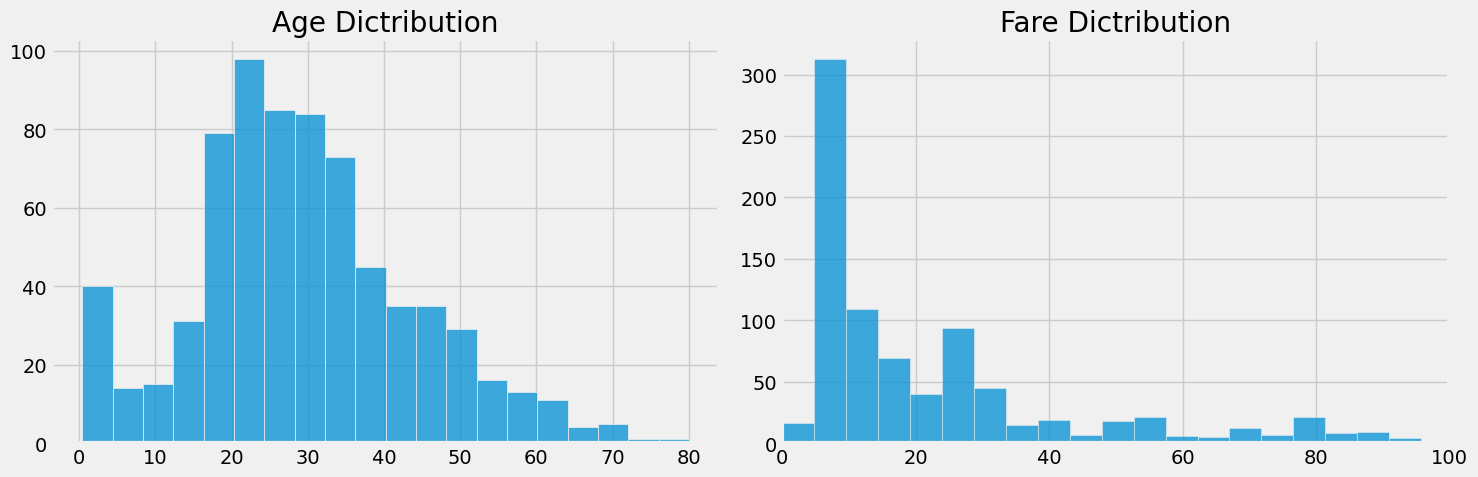

In [69]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15,5))

sns.histplot(df['Age'], ax=ax[0])
ax[0].set_title('Age Dictribution')


sns.histplot(df['Fare'], ax=ax[1])
ax[1].set_xlim(0, 100)
ax[1].set_title('Fare Dictribution')

[(ax[i].set_ylabel(''), ax[i].set_xlabel('')) for i in range(2)]

plt.tight_layout()
plt.show()

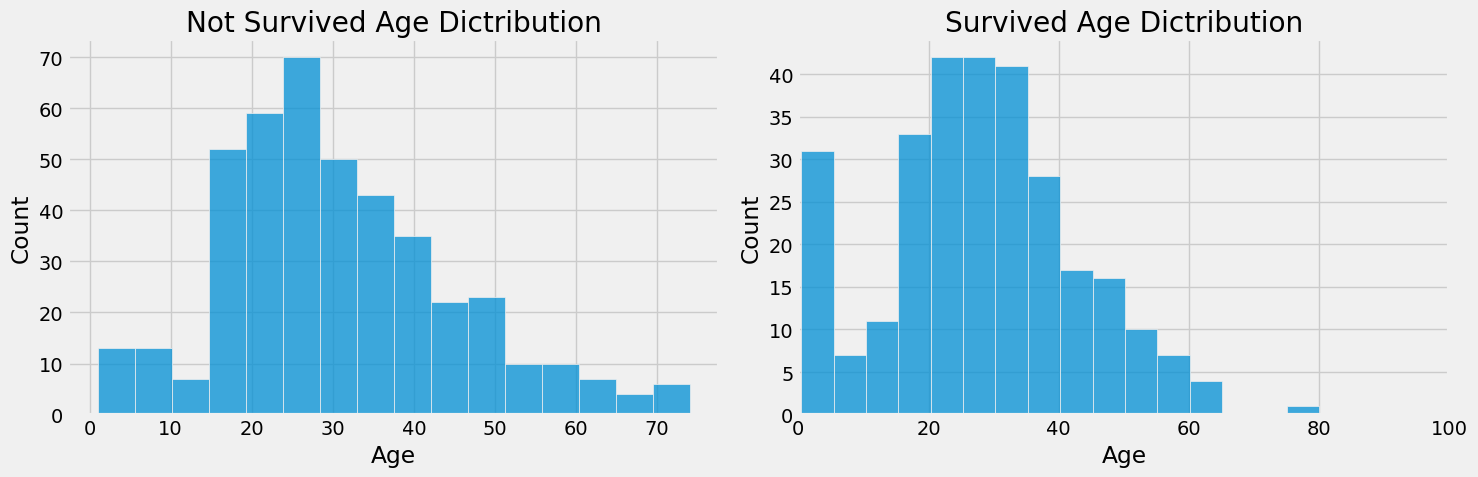

In [70]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15,5))

sns.histplot(df[df[config.target_column_name] == 0]['Age'], ax=ax[0])
ax[0].set_title('Not Survived Age Dictribution')


sns.histplot(df[df[config.target_column_name] == 1]['Age'], ax=ax[1])
ax[1].set_xlim(0, 100)
ax[1].set_title('Survived Age Dictribution')

plt.tight_layout()
plt.show()

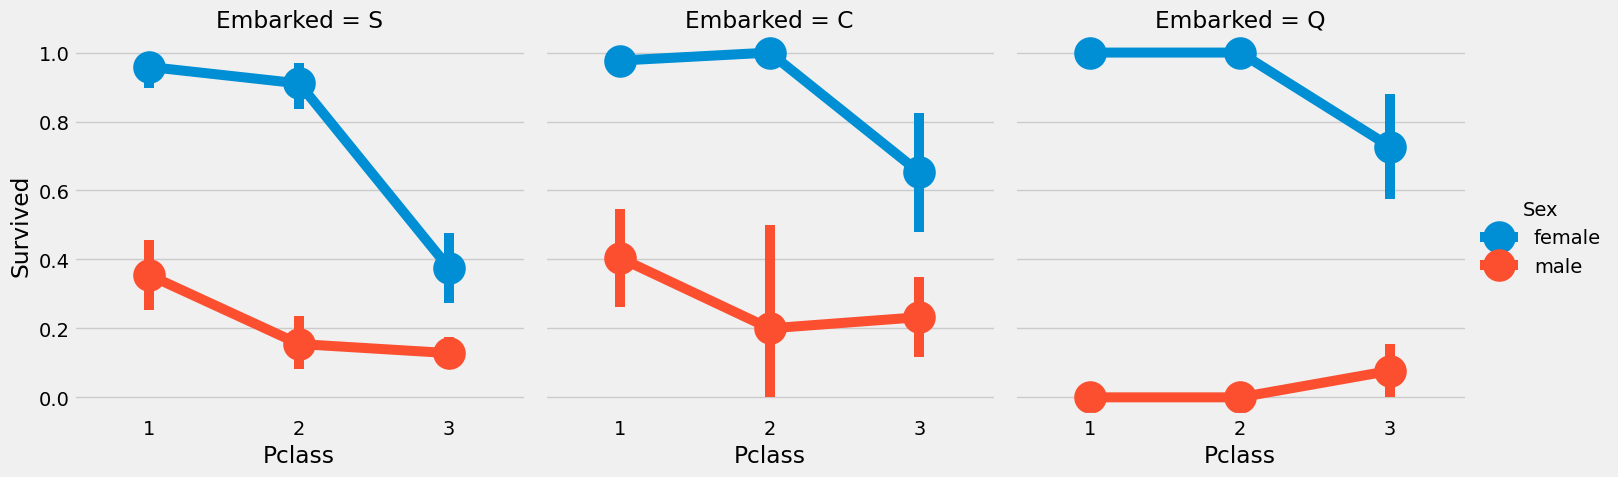

In [71]:
sns.catplot(data=df, x='Pclass',y=config.target_column_name,hue='Sex',col='Embarked', kind='point')
plt.show()

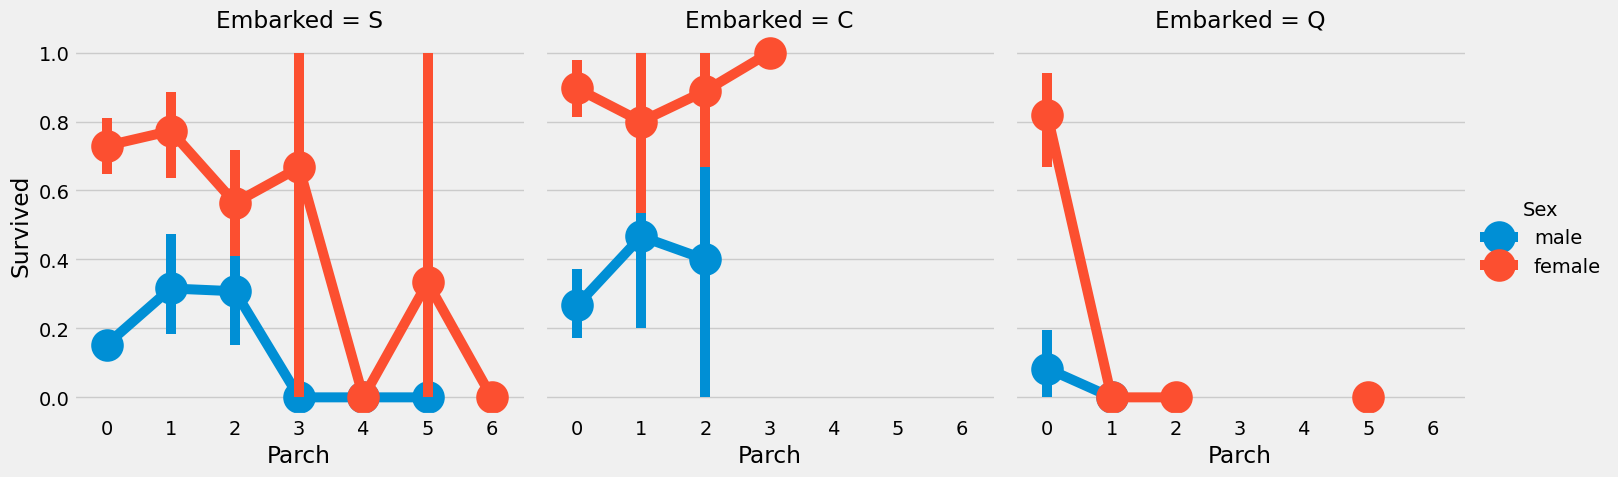

In [72]:
sns.catplot(data=df, x='Parch',y=config.target_column_name,hue='Sex',col='Embarked', kind='point')
plt.show()

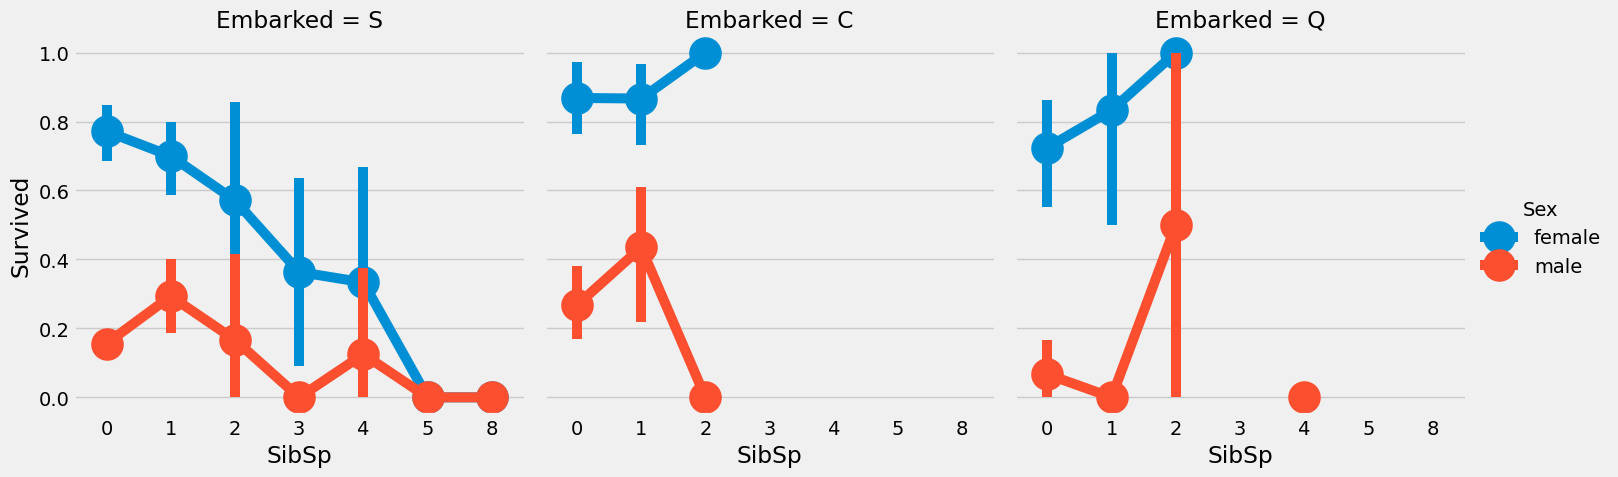

In [73]:
sns.catplot(data=df, x='SibSp',y=config.target_column_name,hue='Sex',col='Embarked', kind='point')
plt.show()

In [74]:
df.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [75]:
df[df['Embarked'].isnull()]

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


In [76]:
# Номера билетов близкие к тем, что у людей с 
# пропусками выезжали из Sauthempton, поэтому 
# есть смысл заполнить их S (Sauthempton)
# Также подавляющее большинство пассажиров садились на борт именно в S (Sauthempton)

df[(df['Pclass'] == 1) & 
   (df['Sex'] == 'female') & 
   (df[config.target_column_name] == 1) & 
   (df['SibSp'] == 0) & 
   (df['Parch'] == 0)]\
   [['Embarked']].value_counts()

Embarked
C           17
S           14
Name: count, dtype: int64

In [77]:
pd.crosstab(df.Parch, df.Pclass, margins=True).style.background_gradient(cmap='summer_r')

Pclass,1,2,3,All
Parch,,,,
0,163,134,381,678
1,31,32,55,118
2,21,16,43,80
3,0,2,3,5
4,1,0,3,4
5,0,0,5,5
6,0,0,1,1
All,216,184,491,891


In [78]:
# fig = plt.figure(figsize=(15,15))
# sns.heatmap(df.drop(columns=['Initial', 'Embarked']).corr(), annot=True)
# plt.show()

In [79]:
# df2 = df.copy(deep=True)

# proc = preprocessor()

# np_array = proc.fit_transform(df2)

# feature_names = proc.get_feature_names_out()

# df2 = pd.DataFrame(np_array, columns=feature_names, index=df2.index)

# fig = plt.figure(figsize=(15,15))
# sns.heatmap(df2.corr())
# plt.show()


### Model

In [6]:
df1 = df.copy(deep=True)

In [7]:
X, y = df1.drop(columns = config.target_column_name, axis = 1), df1[config.target_column_name]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = config.determenism.random_state,
    shuffle=config.determenism.shuffle,
    stratify=y)

#### Linear

In [82]:
# Модель обученная на одном фолде
model = LogisticRegression(penalty=config.linear_model.penalty,
                           C=config.linear_model.C, 
                           l1_ratio=config.linear_model.l1_ratio,
                           solver=config.linear_model.solver,
                           tol=config.linear_model.tol,
                           fit_intercept=config.linear_model.bias,
                           random_state=config.determenism.random_state,
                           max_iter=config.linear_model.max_iter,
                           verbose=config.linear_model.verbose)

pipeline = Pipeline([
        ('preprocessor', preprocessor()),
        ('model', model)
    ])

pipeline.fit(X_train, y_train)
pred = pipeline.predict(X_test)
acc = accuracy_score(pred, y_test)
print(f"acc: {acc}")

res = pipeline_return(pipeline, acc)
add_result(res)


acc: 0.8379888268156425


In [83]:
# Модель обученная на n_splits фолдах
skf = StratifiedKFold(n_splits=config.cv.n_splits,
                      random_state=config.determenism.random_state,
                      shuffle=config.determenism.shuffle)

model = LogisticRegression(penalty=config.linear_model.penalty,
                            C=config.linear_model.C, 
                            l1_ratio=config.linear_model.l1_ratio,
                            solver=config.linear_model.solver,
                            tol=config.linear_model.tol,
                            fit_intercept=config.linear_model.bias,
                            random_state=config.determenism.random_state,
                            max_iter=config.linear_model.max_iter,
                            verbose=config.linear_model.verbose)

pipeline = Pipeline([
        ('preprocessor', preprocessor()),
        ('model', model)
    ])

scores = cross_val_score(pipeline, X_train, y_train, cv=skf, scoring='accuracy')

for fold, score in enumerate(scores, start=1):
    print(f"fold-{fold} accuracy: {score}")

pipeline.fit(X_train, y_train)
    
print(f"\nMean Accuracy: {np.mean(scores)}")

res = pipeline_return(pipeline, scores)
add_result(res)

fold-1 accuracy: 0.7972027972027972
fold-2 accuracy: 0.8181818181818182
fold-3 accuracy: 0.8732394366197183
fold-4 accuracy: 0.7887323943661971
fold-5 accuracy: 0.823943661971831

Mean Accuracy: 0.8202600216684723


In [ ]:
# Модель для автоподбора С
model_cv = LogisticRegressionCV(
                        tol=config.linear_model.tol,
                        fit_intercept=config.linear_model.bias,
                        random_state=config.determenism.random_state,
                        max_iter=config.linear_model.max_iter,
                        solver=config.linear_model.solver,
                        cv=config.linear_model.cv,
                        refit=config.linear_model.refit, # обучит лучшую модель на всех данных
                        Cs=config.linear_model.Cs,
                        verbose=config.linear_model.verbose,
                        scoring=config.linear_model.scoring
                )

pipeline_cv = Pipeline([
        ('preprocessor', preprocessor(True, True)),
        ('model', model_cv)
    ])

pipeline_cv.fit(X_train, y_train)

best_model = pipeline_cv.named_steps['model']
best_C = best_model.C_.item()

scores = best_model.scores_

test_acc = pipeline_cv.score(X_test, y_test)

mean_cv_per_c = np.mean(scores[1], axis=0)
best_cv_score = np.max(mean_cv_per_c).item()

print(f"best C: {best_C}")
print(f"mean acc for best C: {best_cv_score}")
print(f"test accuracy: {test_acc}")

res = pipeline_return(pipeline_cv, best_cv_score)
add_result( res)

best C: 0.046415888336127774
mean acc: 0.8216881709839455
test accuracy: 0.8268156424581006


In [26]:
# Линейная регрессия с регуляризациями
l1_ratios = np.arange(0.25, 0.76, 0.25)
Cs = np.logspace(-4, 1, 6) 
penalties = ['l1', 'l2', 'elasticnet']
results = []
for penalty in penalties:
    for c in Cs:
        if penalty == "l1":
            solver = "liblinear"
        elif penalty == "elasticnet":
            solver = "saga"
        else:
            solver = "lbfgs"

        if penalty == "elasticnet":
            for l1_ratio in l1_ratios:
                res = logistic_kfold(X_train, y_train, penalty=penalty, solver=solver, l1_ratio=l1_ratio, C=c)
                add_result(res)
                print(f"l1_ratio: {l1_ratio} \nC: {c}\n")
        else:
            res = logistic_kfold(X_train, y_train, penalty=penalty, solver=solver, C=c)
            add_result(res)
            print(f"C: {c}\n")

fold-1 accuracy: 0.6153846153846154
fold-2 accuracy: 0.6153846153846154
fold-3 accuracy: 0.6126760563380281
fold-4 accuracy: 0.6197183098591549
fold-5 accuracy: 0.6197183098591549
Mean Accuracy: 0.6165763813651137
C: 0.0001

fold-1 accuracy: 0.6153846153846154
fold-2 accuracy: 0.6153846153846154
fold-3 accuracy: 0.6126760563380281
fold-4 accuracy: 0.6197183098591549
fold-5 accuracy: 0.6197183098591549
Mean Accuracy: 0.6165763813651137
C: 0.001

fold-1 accuracy: 0.6153846153846154
fold-2 accuracy: 0.6153846153846154
fold-3 accuracy: 0.6126760563380281
fold-4 accuracy: 0.6197183098591549
fold-5 accuracy: 0.6197183098591549
Mean Accuracy: 0.6165763813651137
C: 0.01

fold-1 accuracy: 0.8111888111888111
fold-2 accuracy: 0.7692307692307693
fold-3 accuracy: 0.852112676056338
fold-4 accuracy: 0.7887323943661971
fold-5 accuracy: 0.823943661971831
Mean Accuracy: 0.8090416625627892
C: 0.1

fold-1 accuracy: 0.7972027972027972
fold-2 accuracy: 0.8181818181818182
fold-3 accuracy: 0.8732394366197183


#### KNN

In [31]:
pipeline = Pipeline([
        ("preprocessor", preprocessor(is_scale=True, is_cat=True)), 
        ("model", KNeighborsClassifier())
    ])

knn_params = {
        'model__n_neighbors': np.arange(3, 18, 2),
        'model__weights': ['distance', 'uniform'], 
        'model__leaf_size': [20, 30, 50], 
        'model__metric': ['cosine', 'manhattan', 'euclidean']}

grid_search = GridSearchCV(
                estimator=pipeline, 
                param_grid=knn_params,
                scoring=config.linear_model.scoring,  
                refit=config.linear_model.refit, 
                cv=config.cv.n_splits, 
                pre_dispatch='2*n_jobs',  
                return_train_score=False)

grid_search.fit(X_train, y_train)

if config.logs.console:
    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")

best_pipeline = grid_search.best_estimator_
test_preds = best_pipeline.predict(X_test)
final_acc = accuracy_score(y_test, test_preds)

if config.logs.console:
    print(f"X_test Accuracy: {final_acc:.4f}")

res = pipeline_return(best_pipeline, grid_search.best_score_)
add_result(res)

Best Parameters: {'model__leaf_size': 20, 'model__metric': 'euclidean', 'model__n_neighbors': np.int64(9), 'model__weights': 'uniform'}
Best CV Accuracy: 0.8245
X_test Accuracy: 0.8212


#### Trees

##### Decision Tree

In [93]:
# Baseline 

dt = DecisionTreeClassifier(random_state=config.determenism.random_state)

pipeline = Pipeline([
        ('preprocessor', preprocessor(False)),
        ('model', dt)
    ])

scores = cross_val_score(estimator=pipeline, 
                                  X=X_train, 
                                  y=y_train, 
                                  cv=config.cv.n_splits, 
                                  scoring=config.linear_model.scoring)

for fold, score in enumerate(scores, start=1):
    print(f"fold-{fold} accuracy: {score}")

print(f'mean accuracy: {np.mean(scores)}')

pipeline.fit(X_train, y_train)


res = pipeline_return(pipeline, scores)
add_result(res)

fold-1 accuracy: 0.7972027972027972
fold-2 accuracy: 0.7342657342657343
fold-3 accuracy: 0.7816901408450704
fold-4 accuracy: 0.823943661971831
fold-5 accuracy: 0.7887323943661971
mean accuracy: 0.785166945730326


In [94]:
# Baseline 
dt = DecisionTreeClassifier(random_state=config.determenism.random_state)

pipeline = Pipeline([
        ('preprocessor', preprocessor()),
        ('model', dt)
    ])

scores = cross_val_score(estimator=pipeline, 
                                  X=X_train, 
                                  y=y_train, 
                                  cv=config.cv.n_splits, 
                                  scoring=config.linear_model.scoring)

for fold, score in enumerate(scores, start=1):
    print(f"fold-{fold} accuracy: {score}")

print(f'mean accuracy: {np.mean(scores)}')

pipeline.fit(X_train, y_train)


res = pipeline_return(pipeline, scores)
add_result(res)

fold-1 accuracy: 0.7972027972027972
fold-2 accuracy: 0.7342657342657343
fold-3 accuracy: 0.7816901408450704
fold-4 accuracy: 0.8098591549295775
fold-5 accuracy: 0.7887323943661971
mean accuracy: 0.7823500443218753


In [95]:
pipeline = Pipeline([
        ('preprocessor', preprocessor()),
        ('model', DecisionTreeClassifier(random_state=config.determenism.random_state))
    ])

params = {
          'model__max_depth': np.arange(1, 6),
          'model__min_samples_split': [5, 10, 20, 30], 
          'model__min_samples_leaf': [2, 5, 10, 20]
          }

grid_search = GridSearchCV(estimator=pipeline, 
                   param_grid=params,
                   scoring=config.linear_model.scoring,  
                   refit=True, 
                   cv=config.cv.n_splits, 
                   pre_dispatch='2*n_jobs',  
                   return_train_score=False)

grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")

best_pipeline = grid_search.best_estimator_
test_preds = best_pipeline.predict(X_test)
final_acc = accuracy_score(y_test, test_preds)

print(f"X_test Accuracy: {final_acc:.4f}")

res = pipeline_return(best_pipeline, final_acc)
add_result(res)

Best parameters: {'model__max_depth': np.int64(5), 'model__min_samples_leaf': 10, 'model__min_samples_split': 5}
Best CV Accuracy: 0.8091
X_test Accuracy: 0.8212


In [ ]:
def objective(trial):
    params = {
              'max_depth': trial.suggest_int('max_depth', 3, 7), 
              'min_samples_split': trial.suggest_categorical('min_samples_split', [5, 10, 20, 30]), 
              'min_samples_leaf': trial.suggest_categorical('min_samples_leaf', [2, 5, 10, 20]),
              'min_weight_fraction_leaf': trial.suggest_float('min_weight_fraction_leaf', 0.0, 0.2), 
              'max_features': trial.suggest_categorical('max_features', [None, 'sqrt', 'log2', 0.5, 0.8]), 
              'max_leaf_nodes': trial.suggest_categorical('max_leaf_nodes', [None, 5, 10, 25, 50, 100]), 
              'min_impurity_decrease': trial.suggest_float('min_impurity_decrease', 0.0, 0.01)
             }

    dt = DecisionTreeClassifier(**params, 
                                random_state=config.determenism.random_state)

    pipeline = Pipeline([
        ('preprocessor', preprocessor(False)),
        ('model', dt)
    ])

    accuracy = cross_val_score(pipeline, 
                               X_train, 
                               y_train, 
                               cv=config.cv.n_splits, 
                               scoring='accuracy').mean()
    return accuracy


study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

best_params = study.best_params
print(f"Best CV Accuracy: {study.best_value:.4f}")
print(f"Best parameters: {best_params}")


best_dt = DecisionTreeClassifier(**best_params, random_state=config.determenism.random_state)
final_pipeline = Pipeline([
    ('preprocessor', preprocessor()),
    ('model', best_dt)
])

final_pipeline.fit(X_train, y_train)

pred = final_pipeline.predict(X_test)
test_accuracy = accuracy_score(y_test, pred) # Правильный порядок: y_true, y_pred

print(f"X_test Accuracy: {test_accuracy:.4f}")

res = pipeline_return(final_pipeline, study.best_value)
add_result(res)

[I 2026-07-26 11:09:18,385] A new study created in memory with name: no-name-6ad4180a-dcbe-442b-9c7b-4aa77e617622
[I 2026-07-26 11:09:18,615] Trial 0 finished with value: 0.7893627499261302 and parameters: {'max_depth': 6, 'min_samples_split': 30, 'min_samples_leaf': 10, 'min_weight_fraction_leaf': 0.14835948412743175, 'max_features': 'sqrt', 'max_leaf_nodes': 100, 'min_impurity_decrease': 0.006732879323537393}. Best is trial 0 with value: 0.7893627499261302.
[I 2026-07-26 11:09:18,859] Trial 1 finished with value: 0.7992514527725796 and parameters: {'max_depth': 3, 'min_samples_split': 10, 'min_samples_leaf': 20, 'min_weight_fraction_leaf': 0.06291423231921867, 'max_features': 0.5, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.004691876027654442}. Best is trial 1 with value: 0.7992514527725796.
[I 2026-07-26 11:09:19,159] Trial 2 finished with value: 0.8048754062838569 and parameters: {'max_depth': 4, 'min_samples_split': 5, 'min_samples_leaf': 2, 'min_weight_fraction_leaf': 0.04

Best CV Accuracy: 0.8147
Best parameters: {'max_depth': 6, 'min_samples_split': 20, 'min_samples_leaf': 2, 'min_weight_fraction_leaf': 0.017198351940290617, 'max_features': None, 'max_leaf_nodes': 100, 'min_impurity_decrease': 1.745504279474694e-05}
X_test Accuracy: 0.8156


##### Random Forest

[I 2026-07-26 11:09:33,118] A new study created in memory with name: no-name-82fa429d-75b2-4207-b0e7-f04ae694c2c4
[I 2026-07-26 11:09:34,597] Trial 0 finished with value: 0.792169802028957 and parameters: {'n_estimators': 157, 'max_depth': 4, 'min_samples_split': 5, 'min_samples_leaf': 10, 'min_weight_fraction_leaf': 0.030647399675704668, 'max_features': 'sqrt', 'max_leaf_nodes': 100, 'min_impurity_decrease': 0.006934354664046439}. Best is trial 0 with value: 0.792169802028957.
[I 2026-07-26 11:09:38,152] Trial 1 finished with value: 0.7921599527233328 and parameters: {'n_estimators': 409, 'max_depth': 3, 'min_samples_split': 30, 'min_samples_leaf': 5, 'min_weight_fraction_leaf': 0.07285609400688467, 'max_features': 'log2', 'max_leaf_nodes': 25, 'min_impurity_decrease': 0.009136627534875165}. Best is trial 0 with value: 0.792169802028957.
[I 2026-07-26 11:09:40,709] Trial 2 finished with value: 0.8188712695754949 and parameters: {'n_estimators': 252, 'max_depth': 6, 'min_samples_split'

best parameters: {'n_estimators': 504, 'max_depth': 7, 'min_samples_split': 10, 'min_samples_leaf': 5, 'min_weight_fraction_leaf': 0.0002214030350584776, 'max_features': 0.8, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.006456351230346648}
accuracy: 0.8044692737430168


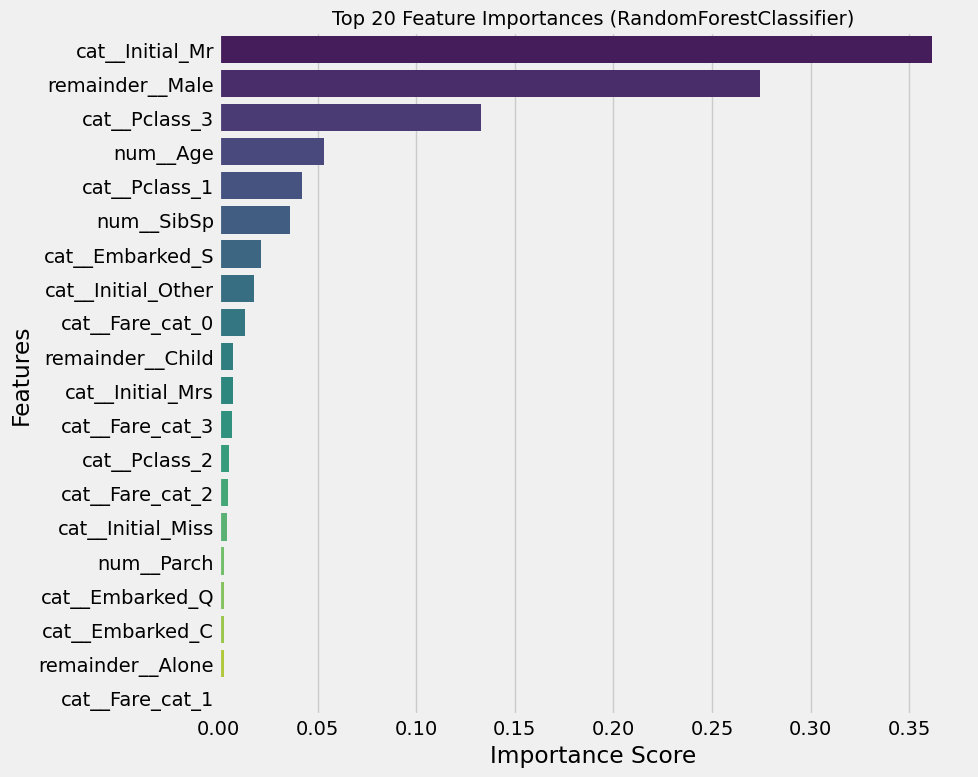

In [97]:
def objective(trial):
    params = {
              "n_estimators": trial.suggest_int('n_estimators', 100, 1000),
              'max_depth': trial.suggest_int('max_depth', 3, 7), 
              'min_samples_split': trial.suggest_categorical('min_samples_split', [5, 10, 20, 30]), 
              'min_samples_leaf': trial.suggest_categorical('min_samples_leaf', [2, 5, 10, 20]),
              'min_weight_fraction_leaf': trial.suggest_float('min_weight_fraction_leaf', 0.0, 0.2), 
              'max_features': trial.suggest_categorical('max_features', [None, 'sqrt', 'log2', 0.5, 0.8]), 
              'max_leaf_nodes': trial.suggest_categorical('max_leaf_nodes', [None, 5, 10, 25, 50, 100]), 
              'min_impurity_decrease': trial.suggest_float('min_impurity_decrease', 0.0, 0.01)
             }

    rf = RandomForestClassifier(**params, 
                                random_state=config.determenism.random_state)

    pipeline = Pipeline([
            ('preprocessor', preprocessor()),
            ('model', rf)
        ])
    
    accuracy = cross_val_score(pipeline, 
                               X_train, 
                               y_train, 
                               cv=config.cv.n_splits, 
                               scoring='accuracy').mean()
    
    return accuracy


study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

best_params = study.best_params

print(f"best parameters: {best_params}")

best_rf = RandomForestClassifier(**best_params, random_state=config.determenism.random_state)
pipeline = Pipeline([
            ('preprocessor', preprocessor()),
            ('model', best_rf)
        ])

pipeline.fit(X_train, y_train)
pred = pipeline.predict(X_test)
accuracy = accuracy_score(pred, y_test)

print(f"accuracy: {accuracy}")

results = []
res = pipeline_return(pipeline, accuracy)
add_result(res)

plot_feature_importance(pipeline.named_steps['model'], pipeline.named_steps['preprocessor'].named_steps['cols_transformer'].get_feature_names_out())

#### Boosting

##### XGboost

In [98]:
model = XGBClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    min_child_weight=3,
    subsample=0.7,
    colsample_bytree=0.7,
    gamma=0.2,
    reg_lambda=3, 
    reg_alpha=0.5, 
    random_state=42,
    n_jobs=-1,
    enable_categorical=True
)

pipeline = Pipeline([
            ('preprocessor', preprocessor(False, False)),
            ('model', model)
        ])

scores = cross_val_score(
                        pipeline, 
                        X_train, 
                        y_train, 
                        cv=config.cv.n_splits, 
                        scoring=config.linear_model.scoring)

print(f"Mean CV Score: {np.mean(scores)}")

pipeline.fit(X_train, y_train)

res = pipeline_return(pipeline, scores)
add_result(res)

Mean CV Score: 0.823076923076923


[I 2026-07-26 11:11:00,504] A new study created in memory with name: no-name-04df99be-76e4-4da0-ab25-e197715a1d0b
[I 2026-07-26 11:11:01,244] Trial 0 finished with value: 0.8132670146754654 and parameters: {'max_depth': 5, 'n_estimators': 180, 'learning_rate': 0.04084042104588805, 'reg_lambda': 0.9177237169539612, 'reg_alpha': 0.6799876776442919, 'min_child_weight': 5, 'subsample': 0.65, 'colsample_bytree': 0.8, 'gamma': 0.05}. Best is trial 0 with value: 0.8132670146754654.
[I 2026-07-26 11:11:01,865] Trial 1 finished with value: 0.8132571653698415 and parameters: {'max_depth': 3, 'n_estimators': 150, 'learning_rate': 0.01844248184749896, 'reg_lambda': 1.1656984566850812, 'reg_alpha': 0.18249506137266924, 'min_child_weight': 8, 'subsample': 0.7, 'colsample_bytree': 0.65, 'gamma': 0.3}. Best is trial 0 with value: 0.8132670146754654.
[I 2026-07-26 11:11:02,542] Trial 2 finished with value: 0.8188712695754947 and parameters: {'max_depth': 3, 'n_estimators': 136, 'learning_rate': 0.03220

accuracy 0.8100558659217877


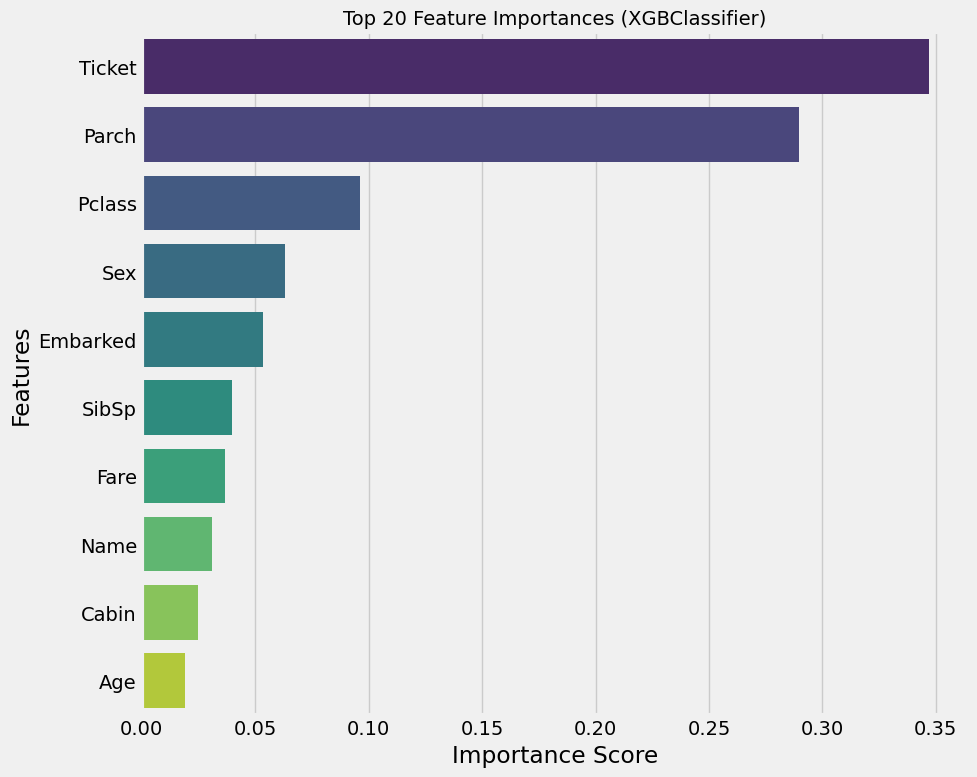

In [99]:
def objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 5),
        'n_estimators': trial.suggest_int('n_estimators', 100, 200),
        
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 5.0, log=True), 
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 2.0, log=True),
        
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        
        'subsample': trial.suggest_float('subsample', 0.6, 0.8, step=0.05),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.8, step=0.05),
        'gamma': trial.suggest_float('gamma', 0.0, 0.3, step=0.05)
    } 

    model = XGBClassifier(
                **params,
                random_state=42,
                n_jobs=-1,
                enable_categorical=True
                )

    pipeline = Pipeline([
                ('preprocessor', preprocessor(False, False)),
                ('model', model)
            ])

    scores = cross_val_score(
                            pipeline, 
                            X_train, 
                            y_train, 
                            cv=config.cv.n_splits, 
                            scoring=config.linear_model.scoring)

    return np.mean(scores)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

best_params = study.best_params  

model = XGBClassifier(
                **best_params,
                random_state=42,
                n_jobs=-1,
                enable_categorical=True
                )

pipeline = Pipeline([
            ('preprocessor', preprocessor(False, False)),
            ('model', model)
        ])

pipeline.fit(X_train, y_train, )

pred = pipeline.predict(X_test)
acc = accuracy_score(y_test, pred)

print(f"accuracy {acc}")

res = pipeline_return(pipeline, acc)
add_result(res)


plot_feature_importance(pipeline.named_steps['model'], X_train.columns)

##### LightGBM

In [100]:
model = LGBMClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    num_leaves=7,             # согласовано с max_depth (2^3 - 1)
    min_child_samples=15,
    subsample=0.7,
    subsample_freq=1,
    colsample_bytree=0.7,
    reg_lambda=3.0, 
    reg_alpha=0.5, 
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

pipeline = Pipeline([
            ('preprocessor', preprocessor(False, False)),
            ('model', model)
        ])

scores = cross_val_score(
                        pipeline, 
                        X_train, 
                        y_train, 
                        cv=config.cv.n_splits, 
                        scoring=config.linear_model.scoring)

print(f"Mean CV Score: {np.mean(scores)}")

pipeline.fit(X_train, y_train)
pred = pipeline.predict(X_test)
acc = accuracy_score(y_test, pred)

print(f"Final Score: {(acc)}")

res = pipeline_return(pipeline, scores)
add_result(res)

Mean CV Score: 0.8245050723923961
Final Score: 0.8100558659217877


[I 2026-07-26 11:11:53,097] A new study created in memory with name: no-name-a70da415-376d-47b4-95eb-48041e70fd67
[I 2026-07-26 11:11:53,898] Trial 0 finished with value: 0.8160642174726682 and parameters: {'max_depth': 4, 'n_estimators': 126, 'learning_rate': 0.029769905659497428, 'reg_lambda': 1.376452009796812, 'reg_alpha': 1.5078667475701821, 'min_child_weight': 6, 'subsample': 0.65, 'colsample_bytree': 0.7, 'gamma': 0.3}. Best is trial 0 with value: 0.8160642174726682.
[I 2026-07-26 11:11:54,589] Trial 1 finished with value: 0.8132670146754654 and parameters: {'max_depth': 4, 'n_estimators': 104, 'learning_rate': 0.012645488880968678, 'reg_lambda': 3.356685718418432, 'reg_alpha': 0.019213374306528648, 'min_child_weight': 8, 'subsample': 0.6, 'colsample_bytree': 0.7, 'gamma': 0.05}. Best is trial 0 with value: 0.8160642174726682.
[I 2026-07-26 11:11:55,280] Trial 2 finished with value: 0.8216783216783217 and parameters: {'max_depth': 3, 'n_estimators': 128, 'learning_rate': 0.01826

accuracy 0.8268156424581006


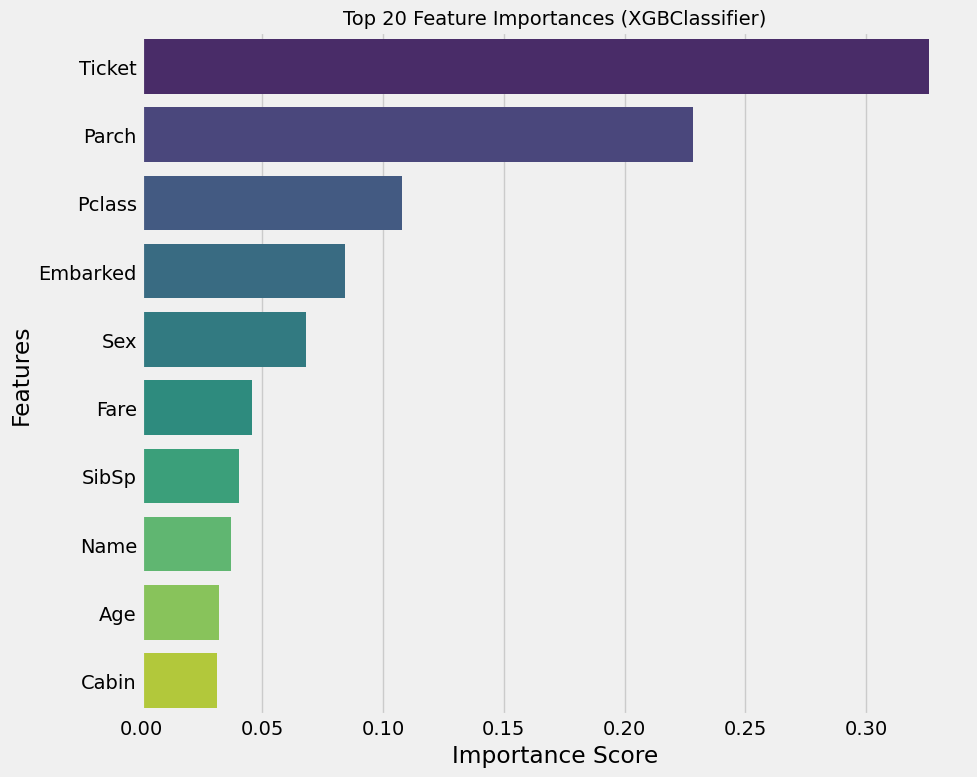

In [ ]:
def objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 5),
        'n_estimators': trial.suggest_int('n_estimators', 100, 200),
        
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 5.0, log=True), 
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 2.0, log=True),
        
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        
        'subsample': trial.suggest_float('subsample', 0.6, 0.8, step=0.05),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.8, step=0.05),
        'gamma': trial.suggest_float('gamma', 0.0, 0.3, step=0.05)
    } 

    model = XGBClassifier(
                **params,
                random_state=42,
                n_jobs=-1,
                enable_categorical=True
                )

    pipeline = Pipeline([
                ('preprocessor', preprocessor(False, False)),
                ('model', model)
            ])

    scores = cross_val_score(
                            pipeline, 
                            X_train, 
                            y_train, 
                            cv=config.cv.n_splits, 
                            scoring=config.linear_model.scoring)

    return np.mean(scores)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

best_params = study.best_params  

model = XGBClassifier(
                **best_params,
                random_state=42,
                n_jobs=-1,
                enable_categorical=True
                )

pipeline = Pipeline([
            ('preprocessor', preprocessor(False, False)),
            ('model', model)
        ])
pipeline.fit(X_train, y_train)
pred = pipeline.predict(X_test)
acc = accuracy_score(y_test, pred)
print(f"accuracy {acc}")

res = pipeline_return(pipeline, acc)
add_result(res)


plot_feature_importance(pipeline.named_steps['model'], X_train.columns)

##### CatBoost

In [21]:
model = CatBoostClassifier(
    random_seed=config.determenism.random_state,
    cat_features=("Embarked", "Initial", "Fare_cat", "Pclass", "Male"),
    # verbose=False,
    # random_state=config.determenism.random_state
)

pipeline = Pipeline(steps=[
    ('feature_engineering', preprocessor(False, False)),
    ('model', model)
])

scores = cross_val_score(estimator=pipeline,
                                  X=X_train, 
                                  y=y_train, 
                                  cv=config.cv.n_splits, 
                                  scoring=config.linear_model.scoring)

print(f"mean cv score: {np.mean(scores)}")

pipeline.fit(X_train, y_train)

res =pipeline_return(pipeline, scores)
add_result(res)

Learning rate set to 0.008098
0:	learn: 0.6895025	total: 15.6ms	remaining: 15.6s
1:	learn: 0.6842189	total: 53.1ms	remaining: 26.5s
2:	learn: 0.6788794	total: 97.5ms	remaining: 32.4s
3:	learn: 0.6739090	total: 141ms	remaining: 35s
4:	learn: 0.6687511	total: 180ms	remaining: 35.8s
5:	learn: 0.6639832	total: 214ms	remaining: 35.4s
6:	learn: 0.6598332	total: 265ms	remaining: 37.6s
7:	learn: 0.6555958	total: 298ms	remaining: 37s
8:	learn: 0.6508429	total: 356ms	remaining: 39.2s
9:	learn: 0.6461427	total: 392ms	remaining: 38.8s
10:	learn: 0.6415894	total: 428ms	remaining: 38.5s
11:	learn: 0.6374752	total: 467ms	remaining: 38.4s
12:	learn: 0.6331901	total: 509ms	remaining: 38.7s
13:	learn: 0.6293364	total: 549ms	remaining: 38.6s
14:	learn: 0.6254247	total: 588ms	remaining: 38.6s
15:	learn: 0.6214724	total: 624ms	remaining: 38.4s
16:	learn: 0.6178493	total: 656ms	remaining: 37.9s
17:	learn: 0.6142174	total: 695ms	remaining: 37.9s
18:	learn: 0.6102862	total: 735ms	remaining: 38s
19:	learn: 0.6

In [25]:
model = CatBoostClassifier(
    random_seed=config.determenism.random_state,
    cat_features=("Embarked", "Initial", "Fare_cat", "Pclass", "Male"),
    verbose=False,
    # random_state=config.determenism.random_state
)

pipeline = Pipeline(steps=[
    ('feature_engineering', preprocessor(False, False)),
    ('model', model)
])
pipeline.fit(X_train, y_train)
pred = pipeline.predict(X_test)
acc = accuracy_score(y_test, pred)
print(f"score: {acc}")

# pipeline.fit(X_train, y_train)

res =pipeline_return(pipeline, scores)
add_result(res)

score: 0.8156424581005587


In [24]:
model = CatBoostClassifier(
    random_seed=config.determenism.random_state,
    # cat_features=("Embarked", "Initial", "Fare_cat", "Pclass", "Male"),
    verbose=False,
    # random_state=config.determenism.random_state
)

pipeline = Pipeline(steps=[
    ('feature_engineering', preprocessor(False, True)),
    ('model', model)
])

scores = cross_val_score(estimator=pipeline,
                                  X=X_train, 
                                  y=y_train, 
                                  cv=config.cv.n_splits, 
                                  scoring=config.linear_model.scoring)

print(f"mean cv score: {np.mean(scores)}")

pipeline.fit(X_train, y_train)

res =pipeline_return(pipeline, scores)
add_result(res)

mean cv score: 0.8174726681768935


In [ ]:
model = CatBoostClassifier(
    random_seed=config.determenism.random_state,
    # cat_features=("Embarked", "Initial", "Fare_cat", "Pclass", "Male"),
    verbose=False,
    # random_state=config.determenism.random_state
)

pipeline = Pipeline(steps=[
    ('feature_engineering', preprocessor(False, True)),
    ('model', model)
])
pipeline.fit(X_train, y_train)
acc = pipeline.predict(X_test)
print(f"score: {acc}")

# pipeline.fit(X_train, y_train)

res =pipeline_return(pipeline, scores)
add_result(res)

In [ ]:
model = CatBoostClassifier(
    iterations=150,
    learning_rate=0.05,
    depth=4,
    l2_leaf_reg=5,
    cat_features=("Embarked", "Initial", "Fare_cat", "Pclass", "Male"),
    bootstrap_type='Bernoulli',     # Включаем стандартный бэггинг строк
    subsample=0.7,                  # Берем 70% объектов на дерево
    rsm=0.7,                        # Берем 70% признаков на дерево
    random_seed=config.determenism.random_state,
    verbose=False,
    random_state=config.determenistic.random_state
)

pipeline = Pipeline(steps=[
    ('feature_engineering', preprocessor(False, False)),
    ('model', model)
])

scores = cross_val_score(estimator=pipeline,
                                  X=X_train, 
                                  y=y_train, 
                                  cv=config.cv.n_splits, 
                                  scoring=config.linear_model.scoring)

print(f"mean cv score: {np.mean(scores)}")

pipeline.fit(X_train, y_train)

res =pipeline_return(pipeline, scores)
add_result(res)

mean cv score: 0.8258839751797499


In [ ]:
def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 200),
        'learning_rate': trial.suggest_float('lr', 0.001, 0.1),
        'depth': trial.suggest_int('depth', 3, 6),
        'l2_leaf_reg': trial.suggest_float('l2', 3, 5),
        # 'bootstrap_type': trial.suggest_categorical(['Bernoulli']),     # Включаем стандартный бэггинг строк
        'subsample': trial.suggest_float('subsample', 0.5, 0.8),        # Берем 70% объектов на дерево
        'rsm': trial.suggest_float('rsm', 0.5, 0.8),                    # Берем 70% признаков на дерево
    }

    model = CatBoostClassifier(**params, 
                               random_seed=config.determenism.random_state, 
                               cat_features=("Embarked", "Initial", "Fare_cat", "Pclass", "Male"),
                               verbose=0)

    pipeline = Pipeline([
            ('preprocessing', preprocessor(False, False)),
            ('model', model)
    ])
    
    scores = cross_val_score(pipeline, 
                                      X_train, 
                                      y_train, 
                                      cv=config.cv.n_splits,
                                      scoring=config.linear_model.scoring)

    return np.mean(scores)



study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

best_params = study.best_params

best_model = CatBoostClassifier(**best_params, 
                                random_seed=config.determenism.random_state, 
                                cat_features=("Embarked", "Initial", "Fare_cat", "Pclass", "Male"),
                                verbose=0)

pipeline = Pipeline([
    ('preprocessing', preprocessor(False, False)),
    ('model', best_model)
])

pipeline.fit(X_train, y_train)
pred = pipeline.predict(X_test)
accuracy = accuracy_score(y_test, pred)

print(f"accuracy: {accuracy}")

res = pipeline_return(pipeline, accuracy)
add_result(res)

accuracy: 0.8044692737430168
